In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

fechas = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
estados = ['Uttar Pradesh', 'Goa', 'Rajasthan', 'Kerala', 'Jammu and Kashmir']

pesos_atractivo = {
    'Uttar Pradesh': 200,
    'Rajasthan': 150,
    'Goa': 130,
    'Kerala': 120,
    'Jammu and Kashmir': 110
}

rutas = [f"{orig} - {dest}" for orig in estados for dest in estados if orig != dest]
car_types = ["luxury_bus", "tourist_van", "train_express"]
payment_methods = ["cash", "card", "upi_mobile"]

data_list = []

# Mapeo de factores para optimizar velocidad de procesamiento
factores_vehiculo = {"train_express": 2.5, "luxury_bus": 1.2, "tourist_van": 0.6}

for ruta in rutas:
    orig, dest = ruta.split(' - ')
    demanda_base_ruta = (pesos_atractivo[orig] + pesos_atractivo[dest]) / 2

    for idx, fecha in enumerate(fechas):
        mes = fecha.month
        dia_semana = fecha.weekday()

        # --- VARIABLE 3: ESTACIONALIDAD REGIONAL ---
        factor_estacional_regional = 1.0
        if dest == 'Jammu and Kashmir':
            if mes in [5, 6, 7, 8]: factor_estacional_regional = 1.8   # Verano: Temporada Alta
            elif mes in [12, 1]: factor_estacional_regional = 0.4      # Invierno: Temporada Baja
        elif dest in ['Goa', 'Kerala']:
            if mes in [11, 12, 1]: factor_estacional_regional = 2.0    # Invierno: Temporada Alta
            elif mes in [6, 7, 8]: factor_estacional_regional = 0.5    # Monzones: Temporada Baja
        elif dest in ['Uttar Pradesh', 'Rajasthan']:
            if mes in [10, 11, 12, 1, 2]: factor_estacional_regional = 1.5 # Clima agradable
            elif mes in [5, 6]: factor_estacional_regional = 0.6              # Calor extremo

        # --- COMPONENTE TEMPORAL Y SEMANAL (Ajustado el bug del domingo) ---
        tendencia = idx * 0.02
        estacionalidad_semanal = 25 if dia_semana in [4, 5] else (-35 if dia_semana == 6 else 0)

        for car in car_types:
            factor_car = factores_vehiculo[car]

            for payment in payment_methods:
                # --- VARIABLE 2: MÉTODO DE PAGO ---
                if payment == "upi_mobile" and (fecha.day in [15, 30, 31]):
                    factor_payment = 15
                elif payment == "card" and dia_semana in [4, 5]:
                    factor_payment = 10
                else:
                    factor_payment = 0

                # --- RUIDO ---
                ruido = np.random.normal(loc=0, scale=8)

                # --- CÁLCULO FINAL ---
                demanda_segmentada = (demanda_base_ruta * factor_estacional_regional * factor_car) \
                                     + tendencia + estacionalidad_semanal + factor_payment + ruido

                demanda_segmentada = max(2, int(demanda_segmentada))

                data_list.append({
                    'fecha': fecha,
                    'ruta': ruta,
                    'origen': orig,
                    'destino': dest,
                    'car_type': car,
                    'payment_method': payment,
                    'demanda_pasajeros': demanda_segmentada
                })

df_complejo = pd.DataFrame(data_list)
df_complejo.to_csv("demanda_transporte_india_final.csv", index=False)
print(f"Dataset generado exitosamente con {df_complejo.shape[0]} registros.")

Dataset generado exitosamente con 131580 registros.


## Procesamiento de Datos


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Cargar el dataset generado en el paso anterior
df = pd.read_csv("demanda_transporte_india_final.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Extraer características numéricas de la fecha (Crucial para Regresión)
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.weekday
df['es_fin_de_semana'] = df['dia_semana'].isin([4, 5]).astype(int) # Viernes y Sábados masivos
df['dia_mes'] = df['fecha'].dt.day

# 3. Aplicar One-Hot Encoding a las variables categóricas (Ruta, Car_Type, Payment_Method, Origen, Destino)
# Esto convierte las palabras en columnas de 0 y 1
df_encoded = pd.get_dummies(df, columns=['ruta', 'car_type', 'payment_method', 'origen', 'destino'], drop_first=True)


X = df_encoded.drop(columns=['fecha', 'demanda_pasajeros'])
y = df_encoded['demanda_pasajeros']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Características preparadas para el modelo: {list(X.columns)}")

Características preparadas para el modelo: ['mes', 'dia_semana', 'es_fin_de_semana', 'dia_mes', 'ruta_Goa - Kerala', 'ruta_Goa - Rajasthan', 'ruta_Goa - Uttar Pradesh', 'ruta_Jammu and Kashmir - Goa', 'ruta_Jammu and Kashmir - Kerala', 'ruta_Jammu and Kashmir - Rajasthan', 'ruta_Jammu and Kashmir - Uttar Pradesh', 'ruta_Kerala - Goa', 'ruta_Kerala - Jammu and Kashmir', 'ruta_Kerala - Rajasthan', 'ruta_Kerala - Uttar Pradesh', 'ruta_Rajasthan - Goa', 'ruta_Rajasthan - Jammu and Kashmir', 'ruta_Rajasthan - Kerala', 'ruta_Rajasthan - Uttar Pradesh', 'ruta_Uttar Pradesh - Goa', 'ruta_Uttar Pradesh - Jammu and Kashmir', 'ruta_Uttar Pradesh - Kerala', 'ruta_Uttar Pradesh - Rajasthan', 'car_type_tourist_van', 'car_type_train_express', 'payment_method_cash', 'payment_method_upi_mobile', 'origen_Jammu and Kashmir', 'origen_Kerala', 'origen_Rajasthan', 'origen_Uttar Pradesh', 'destino_Jammu and Kashmir', 'destino_Kerala', 'destino_Rajasthan', 'destino_Uttar Pradesh']


In [ ]:
# 1. Inicializar y entrenar el modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 2. Realizar predicciones sobre el set de prueba
y_pred = modelo_lineal.predict(X_test)

# 3. Calcular Métricas de Evaluación (Exigidas en la Rúbrica)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} pasajeros")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} pasajeros")


--- METRICAS DE EVALUACIÓN (BASELINE LINEAL) ---
MAE (Error Absoluto Medio): 77.18 pasajeros
RMSE (Raíz del Error Cuadrático Medio): 106.93 pasajeros


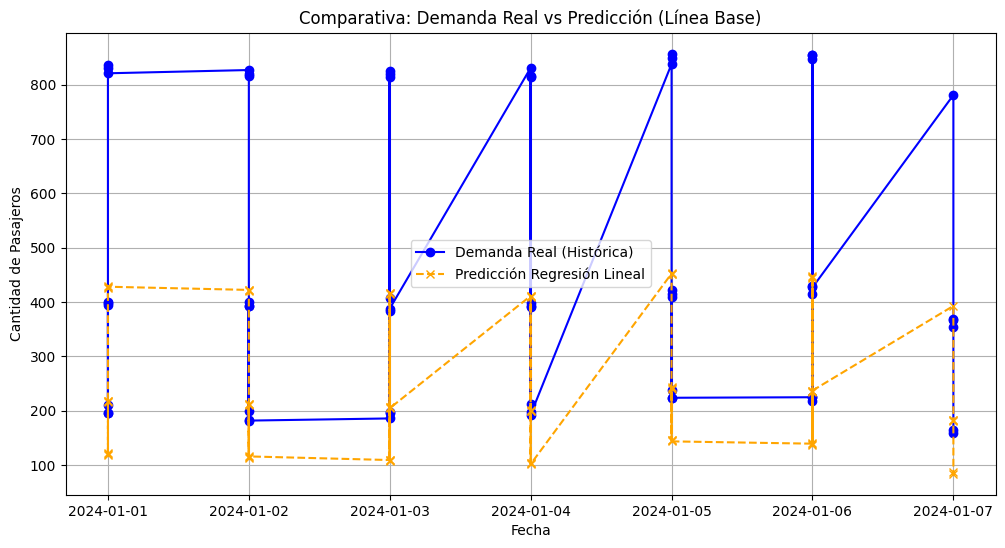

In [10]:
# Crear un subset de prueba ordenado cronológicamente para una visualización clara
df_visualizacion = df_encoded[df_encoded['ruta_Uttar Pradesh - Goa'] == 1].sort_values('fecha').head(60)

X_vis = df_visualizacion.drop(columns=['fecha', 'demanda_pasajeros'])
y_vis = df_visualizacion['demanda_pasajeros']
y_pred_vis = modelo_lineal.predict(X_vis)


plt.figure(figsize=(12, 6))
plt.plot(df_visualizacion['fecha'], y_vis, label='Demanda Real (Histórica)', color='blue', marker='o')
plt.plot(df_visualizacion['fecha'], y_pred_vis, label='Predicción Regresión Lineal', color='orange', linestyle='--', marker='x')
plt.title('Comparativa: Demanda Real vs Predicción (Línea Base)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True)
plt.show()